In [16]:
import bioframe as bf
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt
import pysam
import matplotlib as mpl

In [17]:
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 

In [18]:
HOMER_deseq2_001_out = pd.read_csv('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/HOMER/HOMER_for_deseq2_changed_peaks/HOMER_deseq2_changed_001_out', sep="\t")
HOMER_deseq2_005_out = pd.read_csv('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/HOMER/HOMER_for_deseq2_changed_peaks/HOMER_deseq2_changed_005_out', sep="\t")

In [19]:
df_list_out = [HOMER_deseq2_001_out, HOMER_deseq2_005_out]
df_names_out = ['HOMER_deseq2_001_out', 'HOMER_deseq2_005_out']

dict_df = {}
for name in df_names_out:
    dict_df[name] = pd.DataFrame()

In [20]:
for df, name in zip(df_list_out, dict_df):
    df['Annot_category'] = df.Annotation.str.split().str.get(0)
    df = df.groupby(['Chr', 'Annot_category']).size().reset_index(name='hist_counts')
    df1 = df.groupby('Chr')['hist_counts'].apply(list).reset_index(name='hist_counts')
    df2 = pd.DataFrame(df1['hist_counts'].to_list(), columns=['Intergenic', 'TTS', 'exon', 'intron', 'promoter-TSS'])
    df3 = pd.concat([df1['Chr'], df2], axis=1)
    
    df3 = df3.iloc[ :-1, : ]
    df3 = df3.set_index(['Chr'])
    df3 = df3.fillna(0)
    df3 = df3.astype({'Intergenic':'int', 'TTS':'int', 'exon':'int', 'intron':'int', 'promoter-TSS':'int'})
    dict_df[name] = df3.copy()

Text(0, 0.5, 'Number of peaks')

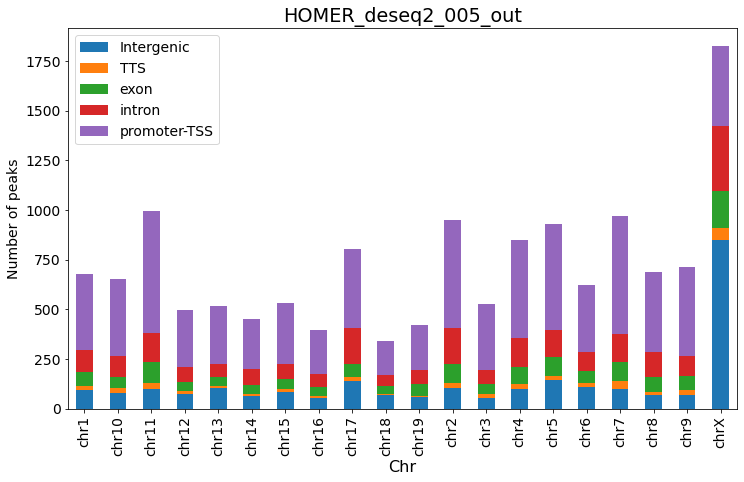

In [21]:
plt.rcParams["figure.figsize"] = (12, 7)

dict_df['HOMER_deseq2_005_out'].plot(kind="bar", stacked=True)
plt.legend(fontsize=14, loc='upper left')

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.title("HOMER_deseq2_005_out")
plt.ylabel("Number of peaks", fontsize=14)
#plt.savefig('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Figures_SFB_poster/DeSeq2_HOMER_001_all_chrom.png', dpi=300)

Text(0, 0.5, 'Peaks falling into category (%)')

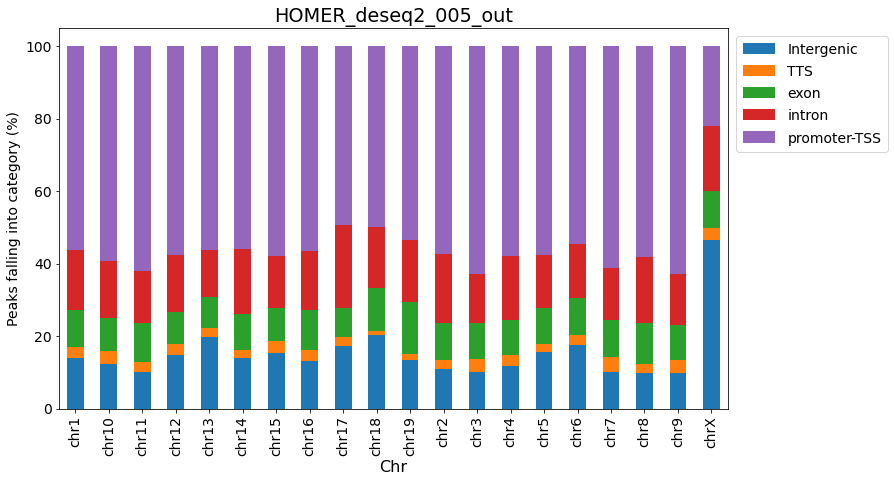

In [22]:
plt.rcParams["figure.figsize"] = (12, 7)

HOMER_deseq2_005_f = dict_df['HOMER_deseq2_005_out'].apply(lambda x: x*100/sum(x), axis=1)

HOMER_deseq2_005_f.plot(kind="bar", stacked=True)
#plt.legend(fontsize=14, loc='upper left')

plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

legend = plt.legend(bbox_to_anchor=(1.00, 1), loc='upper left')
for label in legend.get_texts():
    label.set_fontsize(14)

plt.title("HOMER_deseq2_005_out")
plt.ylabel("Peaks falling into category (%)", fontsize=14)
#plt.savefig('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Figures_SFB_poster/DeSeq2_HOMER_001_all_chrom_f.png', dpi=300)

In [23]:
average0 = dict_df['HOMER_deseq2_001_out'].iloc[:-1, :].mean()
chrX_row0 = dict_df['HOMER_deseq2_001_out'].loc['chrX']
deseq2_001_avr = pd.DataFrame([average0, chrX_row0], index=['Avr_Chr', 'chrX'])
deseq2_001_avr = deseq2_001_avr.astype({'Intergenic':'int', 'TTS':'int', 'exon':'int', 'intron':'int', 'promoter-TSS':'int'})

In [24]:
average = dict_df['HOMER_deseq2_005_out'].iloc[:-1, :].mean()
chrX_row = dict_df['HOMER_deseq2_005_out'].loc['chrX']
deseq2_005_avr = pd.DataFrame([average, chrX_row], index=['Avr_Chr', 'chrX'])
deseq2_005_avr = deseq2_005_avr.astype({'Intergenic':'int', 'TTS':'int', 'exon':'int', 'intron':'int', 'promoter-TSS':'int'})

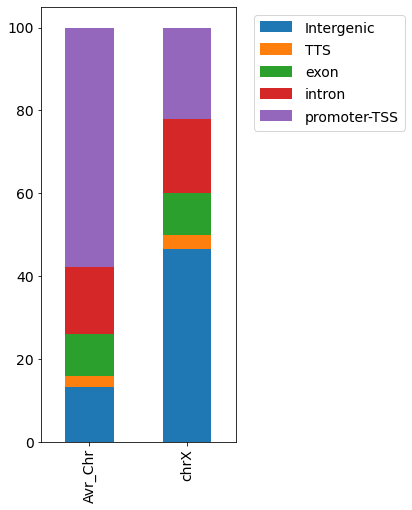

In [30]:
plt.rcParams["figure.figsize"] = (3.5, 8)

deseq2_005_avr_f = deseq2_005_avr.apply(lambda x: x*100/sum(x), axis=1)

deseq2_005_avr_f.plot(kind="bar", stacked=True)

legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for label in legend.get_texts():
    label.set_fontsize(14)

#plt.ylim(0,101)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.show()
#plt.savefig("Percentage_changed_ATAC_peaks_FDR005.pdf", dpi=300, bbox_inches="tight", pad_inches=1)


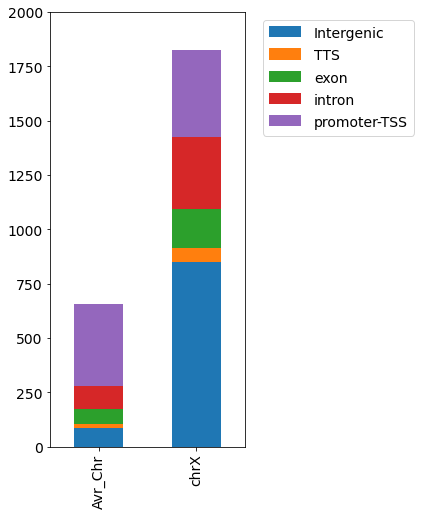

In [31]:
plt.rcParams["figure.figsize"] = (3.5, 8)

deseq2_005_avr.plot(kind="bar", stacked=True)

legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for label in legend.get_texts():
    label.set_fontsize(14)

plt.ylim(0,2000)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

plt.show()
# plt.savefig("Changed_ATAC_peaks_FDR005.pdf", dpi=300, bbox_inches="tight", pad_inches=1)


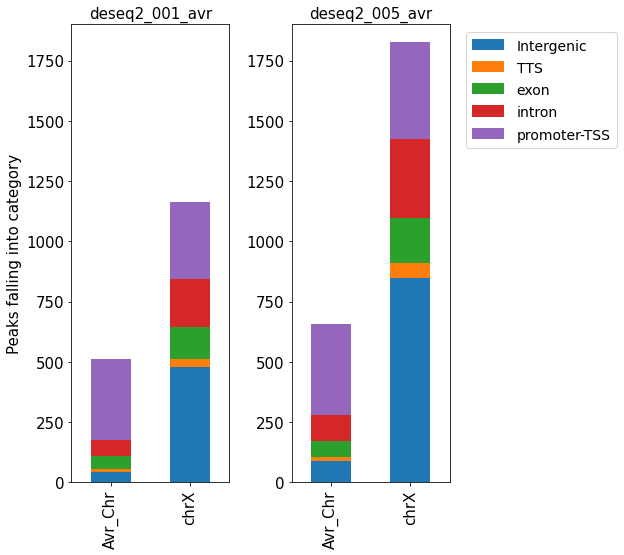

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(9, 8))

dataframes = [deseq2_001_avr, deseq2_005_avr]
titles = ['deseq2_001_avr', 'deseq2_005_avr']

# Loop through each subplot and DataFrame
for i, (ax, df, t) in enumerate(zip(axs, dataframes, titles)):

    # Plot the DataFrame, customize the plot as needed
    df.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(t, fontsize=15)  # Use the index (e.g., 'Autosmomes_avr' or 'chrX') as the title
    ax.tick_params(axis='both', labelsize=15)
    ax.set_ylim(0, 1900)
    if i == 0:
        ax.set_ylabel("Peaks falling into category", fontsize=15)

# Create a common legend outside the plots
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for label in legend.get_texts():
    label.set_fontsize(14)  # Adjust the fontsize as needed

# Adjust spacing between subplots
plt.tight_layout()

#plt.savefig('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Figures_SFB_poster/DeSeq2_HOMER_001_and_005.png', dpi=300)

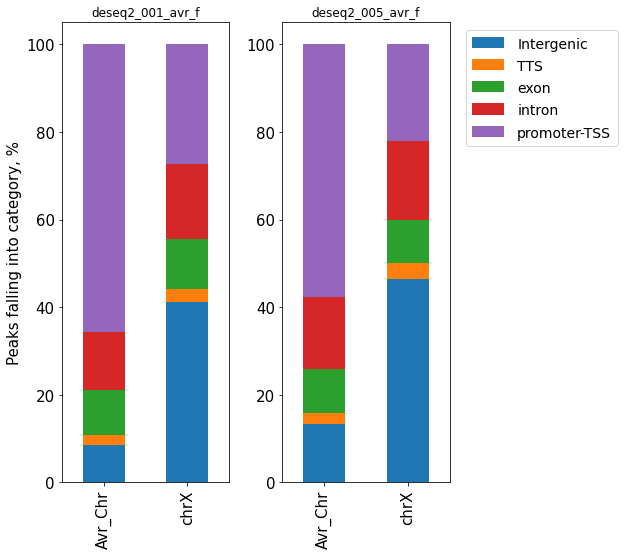

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(9, 8))

deseq2_001_avr_f = deseq2_001_avr.apply(lambda x: x*100/sum(x), axis=1)
deseq2_005_avr_f = deseq2_005_avr.apply(lambda x: x*100/sum(x), axis=1)

dataframes = [deseq2_001_avr_f, deseq2_005_avr_f]
titles = ['deseq2_001_avr_f', 'deseq2_005_avr_f']

# Loop through each subplot and DataFrame
for i, (ax, df, t) in enumerate(zip(axs, dataframes, titles)):

    # Plot the DataFrame, customize the plot as needed
    df.plot(kind="bar", stacked=True, ax=ax, legend=False)
    ax.set_title(t, fontsize=12)  # Use the index (e.g., 'Autosmomes_avr' or 'chrX') as the title
    ax.tick_params(axis='both', labelsize=15)
#    ax.set_ylim(0, 1900)
    if i == 0:
        ax.set_ylabel("Peaks falling into category, %", fontsize=15)

# Create a common legend outside the plots
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
legend = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for label in legend.get_texts():
    label.set_fontsize(14)  # Adjust the fontsize as needed

# Adjust spacing between subplots
plt.tight_layout()

# plt.savefig('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Figures_SFB_poster/DeSeq2_HOMER_001_and_005_f.png', dpi=300)